First 5 Rows
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

Dataset Shape
(100836, 4)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None

Missing Values
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Statistical Summary
              userId        movieId         rating     timestamp
count  100836.000000  100836.000000  100836.000000  1.008360e+05
mean      326.127564   19435.295718       3.501557  1.205946e+09
st

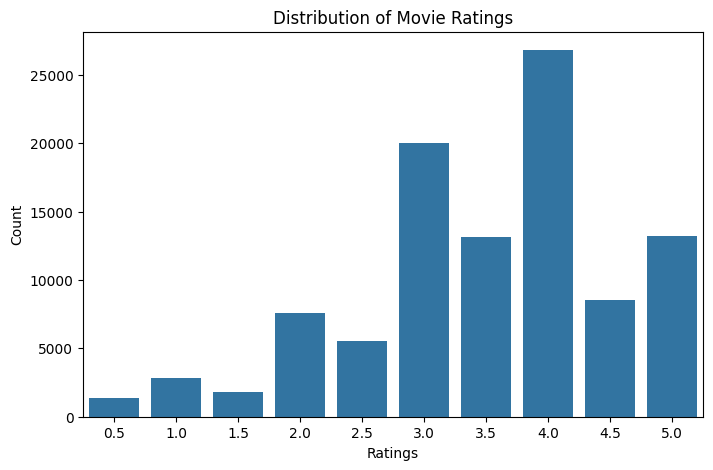

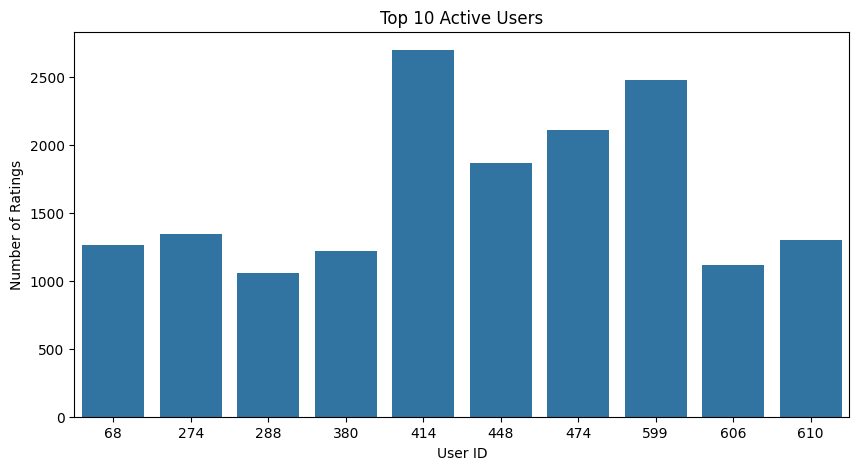

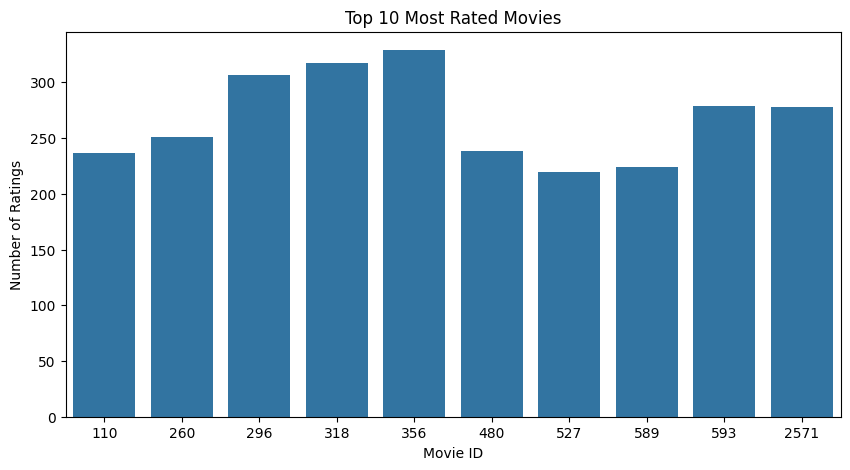

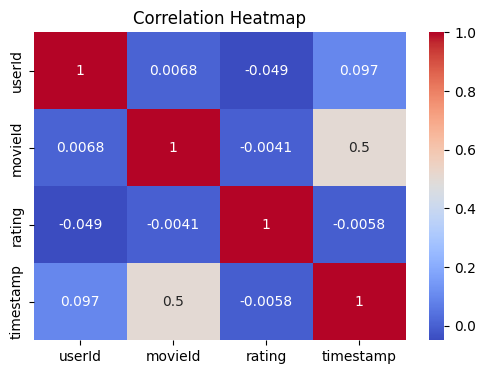


===== Model Evaluation =====
MAE : 0.835
MSE : 1.098
R2 Score : 0.002

===== Predicted Rating =====
User 5 may rate Movie 200 as:
3.6

Prediction file saved successfully!

Sample Predictions
   Actual Rating  Predicted Rating
0            4.5          3.468019
1            3.0          3.515040
2            3.0          3.424625
3            4.0          3.586178
4            4.0          3.576706


In [4]:
# ==================================
# MOVIE RATING PREDICTION PROJECT
# ==================================

# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==================================
# Step 2: Load Dataset
# ==================================

df = pd.read_csv("ratings.csv")

# ==================================
# Step 3: Basic Information
# ==================================

print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nStatistical Summary")
print(df.describe())

# ==================================
# Step 4: Exploratory Data Analysis
# ==================================

# -------- Visualization 1 --------
# Distribution of Ratings

plt.figure(figsize=(8,5))

sns.countplot(
    x='rating',
    data=df
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Ratings")
plt.ylabel("Count")

plt.show()

# -------- Visualization 2 --------
# Top Active Users

top_users = df['userId'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_users.index,
    y=top_users.values
)

plt.title("Top 10 Active Users")
plt.xlabel("User ID")
plt.ylabel("Number of Ratings")

plt.show()

# -------- Visualization 3 --------
# Most Rated Movies

top_movies = df['movieId'].value_counts().head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_movies.index,
    y=top_movies.values
)

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie ID")
plt.ylabel("Number of Ratings")

plt.show()

# -------- Visualization 4 --------
# Correlation Heatmap

plt.figure(figsize=(6,4))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# ==================================
# Step 5: Feature Selection
# ==================================

X = df[['userId', 'movieId']]
y = df['rating']

# ==================================
# Step 6: Train Test Split
# ==================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ==================================
# Step 7: Train Model
# ==================================

model = LinearRegression()

model.fit(X_train, y_train)

# ==================================
# Step 8: Predictions
# ==================================

predictions = model.predict(X_test)

# ==================================
# Step 9: Evaluation
# ==================================

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\n===== Model Evaluation =====")

print("MAE :", round(mae, 3))
print("MSE :", round(mse, 3))
print("R2 Score :", round(r2, 3))

# ==================================
# Step 10: Predict New Rating
# ==================================

user_id = 5
movie_id = 200

new_data = pd.DataFrame({
    'userId': [user_id],
    'movieId': [movie_id]
})

new_prediction = model.predict(new_data)

print("\n===== Predicted Rating =====")

print(f"User {user_id} may rate Movie {movie_id} as:")
print(round(new_prediction[0], 2))

# ==================================
# Step 11: Save Predictions
# ==================================

results = pd.DataFrame({
    'Actual Rating': y_test.values,
    'Predicted Rating': predictions
})

results.to_csv("movie_predictions.csv", index=False)

print("\nPrediction file saved successfully!")

# ==================================
# Step 12: Show Predictions
# ==================================

print("\nSample Predictions")
print(results.head())